In [8]:
import pandas as pd
import numpy as np

In [10]:
df=pd.read_csv(r'C:\Users\Shiva yadav\OneDrive\Documents\Job_Market_Dataset.csv')

In [11]:
df.head()

,Job_ID,Job_Title,Job_Category,Location,Year,Company,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA,Employment_Type
0,1,Data Analyst,Data,Bangalore,2023,TCS,1,4,8,Full-Time
1,2,Data Scientist,Data,Bangalore,2024,Infosys,2,8,18,Full-Time
2,3,Business Analyst,Business,Hyderabad,2023,Accenture,2,6,12,Full-Time
3,4,ML Engineer,AI/ML,Bangalore,2025,Google,3,15,30,Full-Time
4,5,Power BI Developer,BI,Chennai,2024,Wipro,1,5,10,Full-Time


##DATA EPLORATION

In [12]:
df.shape

(40, 10)

In [13]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Job_ID                     40 non-null     int64
 1   Job_Title                  40 non-null     str  
 2   Job_Category               40 non-null     str  
 3   Location                   40 non-null     str  
 4   Year                       40 non-null     int64
 5   Company                    40 non-null     str  
 6   Experience_Required_Years  40 non-null     int64
 7   Salary_Min_LPA             40 non-null     int64
 8   Salary_Max_LPA             40 non-null     int64
 9   Employment_Type            40 non-null     str  
dtypes: int64(5), str(5)
memory usage: 4.8 KB
None


In [14]:
df.dtypes

Job_ID                       int64
Job_Title                      str
Job_Category                   str
Location                       str
Year                         int64
Company                        str
Experience_Required_Years    int64
Salary_Min_LPA               int64
Salary_Max_LPA               int64
Employment_Type                str
dtype: object

In [15]:
print(df.describe())

          Job_ID        Year  Experience_Required_Years  Salary_Min_LPA  \
count  40.000000    40.00000                  40.000000       40.000000   
mean   20.500000  2024.07500                   2.125000        8.750000   
std    11.690452     0.79703                   1.066687        5.057363   
min     1.000000  2023.00000                   0.000000        3.000000   
25%    10.750000  2023.00000                   1.000000        4.750000   
50%    20.500000  2024.00000                   2.000000        7.000000   
75%    30.250000  2025.00000                   3.000000       11.250000   
max    40.000000  2025.00000                   4.000000       20.000000   

       Salary_Max_LPA  
count        40.00000  
mean         17.32500  
std           9.41463  
min           6.00000  
25%           9.75000  
50%          15.00000  
75%          21.25000  
max          40.00000  


##Data Cleaning

In [16]:
df.isnull().sum()

Job_ID                       0
Job_Title                    0
Job_Category                 0
Location                     0
Year                         0
Company                      0
Experience_Required_Years    0
Salary_Min_LPA               0
Salary_Max_LPA               0
Employment_Type              0
dtype: int64

In [17]:
print(df.duplicated())

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
dtype: bool


In [18]:
df['Year'].skew().mean()*100

np.float64(-13.81330237219621)

##OUTLIERS

In [19]:
a=df.select_dtypes(include=['int'])

In [20]:
a.head()

,Job_ID,Year,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA
0,1,2023,1,4,8
1,2,2024,2,8,18
2,3,2023,2,6,12
3,4,2025,3,15,30
4,5,2024,1,5,10


<Axes: >

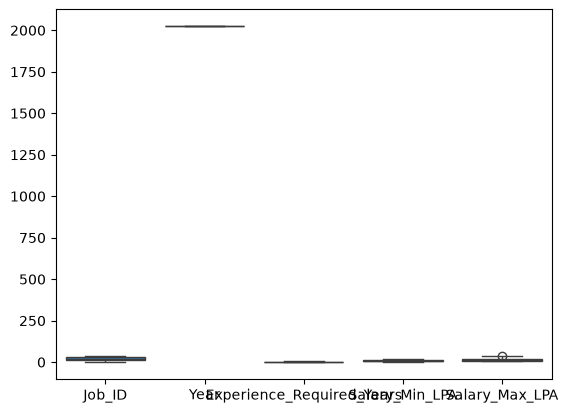

In [21]:
import seaborn as sns
sns.boxplot([a['Job_ID'],a['Year'],a['Experience_Required_Years'],a['Salary_Min_LPA'],a['Salary_Max_LPA']])

##DATA ANALYSIS

In [22]:
df.head()

,Job_ID,Job_Title,Job_Category,Location,Year,Company,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA,Employment_Type
0,1,Data Analyst,Data,Bangalore,2023,TCS,1,4,8,Full-Time
1,2,Data Scientist,Data,Bangalore,2024,Infosys,2,8,18,Full-Time
2,3,Business Analyst,Business,Hyderabad,2023,Accenture,2,6,12,Full-Time
3,4,ML Engineer,AI/ML,Bangalore,2025,Google,3,15,30,Full-Time
4,5,Power BI Developer,BI,Chennai,2024,Wipro,1,5,10,Full-Time


In [24]:
a=df.groupby('Job_Title')['Salary_Max_LPA'].mean().sort_values().head()

In [25]:
b=df.groupby('Job_Category')['Experience_Required_Years'].count().sort_values().head()

In [51]:
c=df['Job_Category'].value_counts().head(5)

In [27]:
d=df.groupby('Company')['Salary_Max_LPA'].mean().sort_values(ascending=False).head()

In [28]:
e=df.groupby('Job_Category')['Salary_Max_LPA'].mean().sort_values(ascending=False).head()

In [29]:
f=df['Job_Title'].value_counts().head()

##DATA VISUALIZATION

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

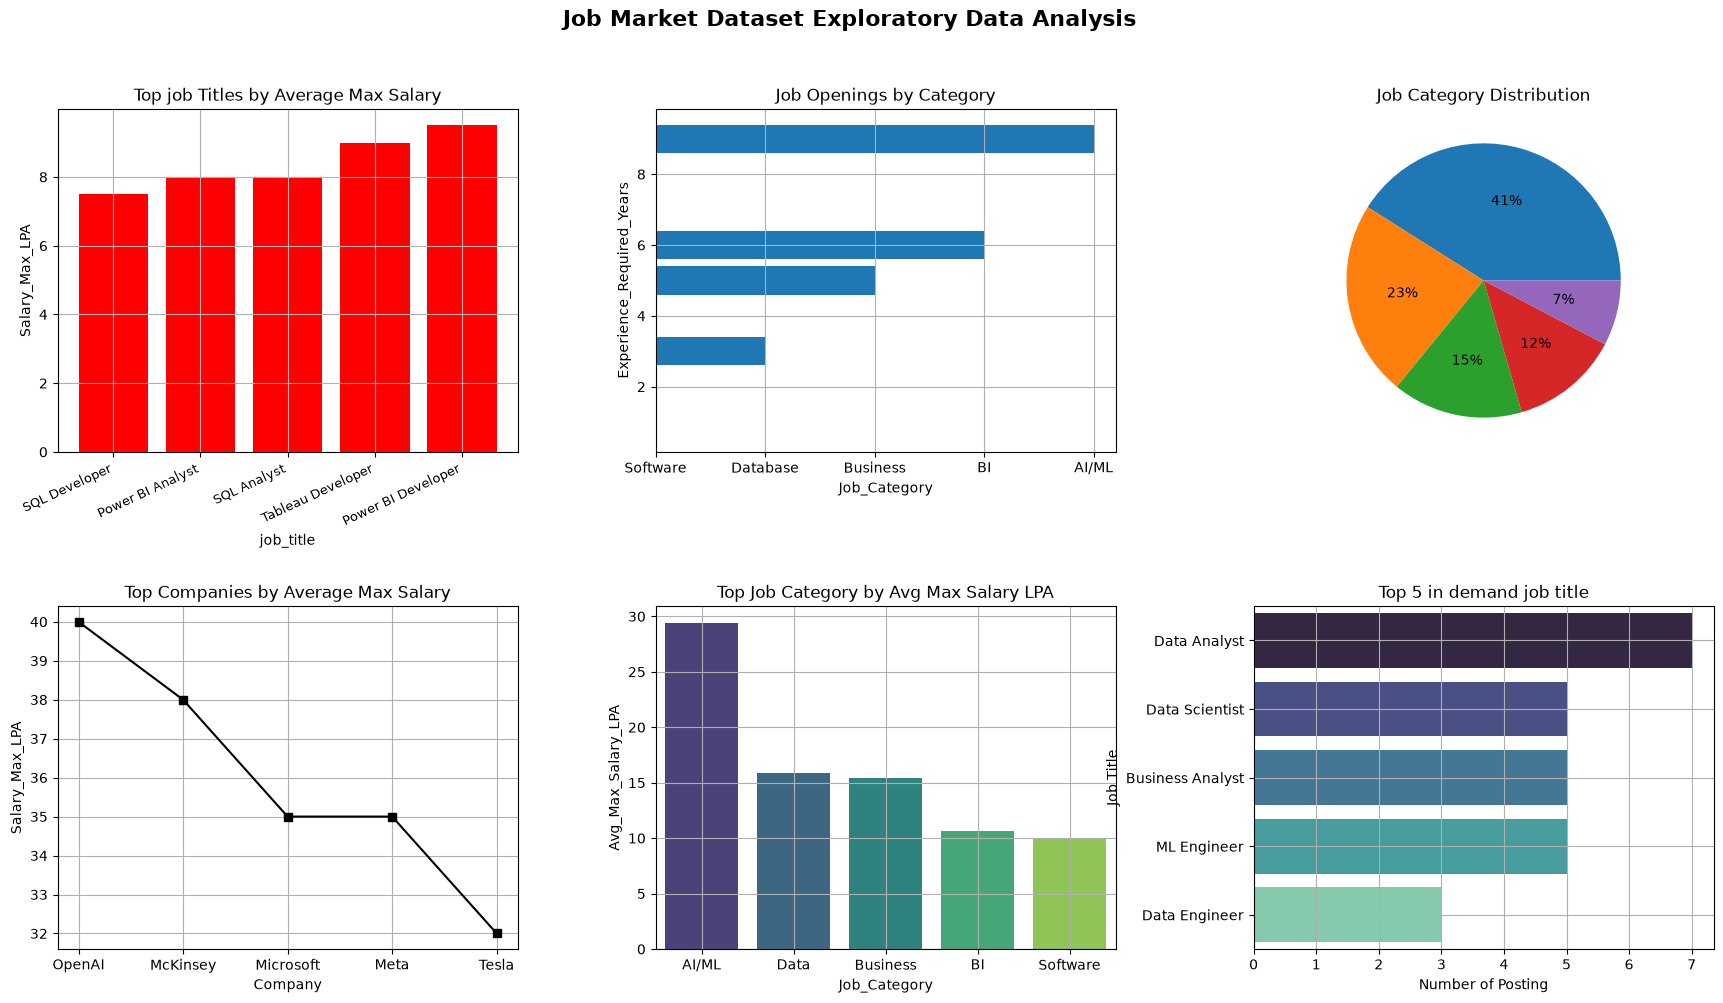

In [76]:
plt.figure(figsize=(18,10))
plt.subplot(2,3,1)
plt.bar(a.index,a.values,color='Red')
plt.title('Top job Titles by Average Max Salary')
plt.grid(True)
plt.xlabel('job_title')
plt.ylabel('Salary_Max_LPA')
plt.xticks(rotation=25,ha='right',fontsize=9)
plt.subplot(2,3,2)
plt.barh(b.values,b.index)
plt.title('Job Openings by Category')
plt.grid(True)
plt.xlabel('Job_Category')
plt.ylabel('Experience_Required_Years')
plt.subplot(2,3,3)
plt.pie(c.values,autopct='%1d%%')
plt.title('Job Category Distribution')
plt.subplot(2,3,4)
plt.plot(d.index,d.values,marker='s',color='black')
plt.title('Top Companies by Average Max Salary')
plt.grid(True)
plt.xlabel('Company')
plt.ylabel('Salary_Max_LPA')
plt.subplot(2,3,5)
sns.barplot(x=e.index,y=e.values, hue=e.index,palette='viridis',legend=False)
plt.grid(True)
plt.title('Top Job Category by Avg Max Salary LPA')
plt.xlabel('Job_Category')
plt.ylabel('Avg_Max_Salary_LPA')
plt.subplot(2,3,6)
sns.barplot(x=f.values,y=f.index,hue=f.index,palette='mako',legend=False)
plt.title('Top 5 in demand job title')
plt.grid(True)
plt.xlabel('Number of Posting')
plt.ylabel('Job Title')
plt.suptitle('Job Market Dataset Exploratory Data Analysis',fontsize=16,fontweight='bold',y=1.02)
plt.subplots_adjust(top=0.92,bottom=0.08,left=0.06,right=0.98,hspace=0.45,wspace=0.30)
plt.savefig('Job Market_eda_dashboard.png')
plt.show()